# Assignment 3 - Building a Simplified Transformer for Sentiment Analysis

This file implement simplified Transformer from scratch to classify the perform sentiment analysis on IMDb dataset..

In [ ]:
# import relevant libraries
import torch
from torch.utils.data import DataLoader # to prepare for DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer

from train_utils import train, test # Shared training/testing function across all notebook file
from transformer_encoder import TransformerEncoder # Shared Transformer encoder architecture across all notebook file


### 1. Load The IMDb Dataset, Preprocessing, and Dataset Handling

In [9]:
# load the dataset
imdb_dataset = load_dataset('stanfordnlp/imdb')

In [10]:
target_names = ['negative','positive'] # how can I know 0=negative, 1=positive?

In [14]:
# setting the tokenizer
tokeniser_name = 'bert-base-uncased'
tokeniser = AutoTokenizer.from_pretrained(tokeniser_name)
print(tokeniser)

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


#### Limit the tokeniser vocabulary size

The default `bert-base-uncased` vocabulary (30,522 tokens) makes the embedding table the dominant source of model parameters, which drives overfitting on this 25,000-review dataset. The cell below retrains the same WordPiece tokeniser on the IMDb train corpus with a much smaller target vocabulary.

In [15]:
# limit the vocabulary size of the tokeniser (change this value to experiment with vocab capacity later)
custom_vocab_size = 20000

def get_training_corpus(dataset, batch_size=1000):
    """
    Yield the review text in batches for the tokeniser trainer.

    Args:
        dataset: HuggingFace dataset split containing a "text" column.
        batch_size (int): Number of reviews yielded per batch.

    Returns:
        generator: Batches of raw review text strings.
    """
    for i in range(0, len(dataset["text"]), batch_size):
        yield dataset["text"][i : i + batch_size]

# retrain the bert-base-uncased WordPiece tokeniser on the IMDb train corpus, capped at custom_vocab_size tokens
tokeniser = tokeniser.train_new_from_iterator(
    get_training_corpus(imdb_dataset["train"]),
    vocab_size=custom_vocab_size
)

print(tokeniser)
print(f"New tokeniser vocab size: {tokeniser.vocab_size}")

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=20000, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})
New tokeniser vocab size: 20000


In [16]:
# define the tokenisation function
def tokenise_function(examples):
    return tokeniser(
        examples["text"],
        padding = "max_length",
        truncation = True,
        max_length = 600
    )

In [17]:
# tokenise the dataset
tokenised_datasets = imdb_dataset.map(tokenise_function, batched=True)

tokenised_datasets = tokenised_datasets.select_columns(["input_ids", "attention_mask", "label"])
tokenised_datasets.set_format("torch")

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [18]:
# create PyToch DataLoaders
train_dataloader = DataLoader(
    tokenised_datasets["train"],
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    tokenised_datasets["test"],
    batch_size=32,
    shuffle=False
)

In [19]:
# show information of the datasets per batch
for batch in train_dataloader:
    print("Input IDs shape:", batch["input_ids"].shape)          # [32, 512]
    print("Attention Mask shape:", batch["attention_mask"].shape)  # [32, 512]
    print("Labels shape:", batch["label"].shape)                 # [32]
    break

Input IDs shape: torch.Size([32, 600])
Attention Mask shape: torch.Size([32, 600])
Labels shape: torch.Size([32])


### 2. Transformers Implementation

**1. Architecture Requirements**
- **Input Embedding Layer**:
    - Convert input text to token embeddings using a simple word embedding layer.
    - Use torch.nn.Embedding or implement your own.
- **Positional Encoding**:
    - Add positional encodings to input embeddings to incorporate sequential information.
- **Self-Attention Mechanism**:
    - Implement scaled dot-product attention: $$\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right) V$$
    - Use multi-head attention for richer feature representations.
- **Feedforward Network**:
    - Add a two-layer feedforward network with ReLU activation.
- **Classification Head**:
    - Use a fully connected layer to map the output of the Transformer to a binary label (positive or negative).
- **Architecture Summary**:
    - Input → Embedding → Positional Encoding → Multi-Head Attention → Feedforward → Classification Head → Output

**2. Forward Propagation**
- Implement tokenization, embedding, attention computation, and feedforward operations.
- Use softmax activation in the output layer for binary classification probabilities.

**3. Backward Propagation**
- Compute gradients for all weights using binary cross-entropy loss.
- Update weights using **Adam Optimizer**.

**4. Training Loop**
- Train the Transformer for **10** epochs with:
    - Batch size: **32**
    - Learning rate: **0.001**
- Use mini-batch processing.

**5. Evaluation**
- Evaluate the model on the IMDb test set.
- Calculate and report **accuracy, precision, recall, and F1-score**.

The encoder block of Transformers consist of (in order):
- Multi-head attention
- Residual connection and layer normalisation
- Fully connected feed-forward network
- Residual connection and layer normalisation


### 3. Training Phase

In [27]:
# detect the device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [28]:
# instantiate the model
encoder = TransformerEncoder(
    num_layers=4, # number of encoder block
    d_model=64, # width of every token vector representation
    num_heads=4, # head dim is d_model / num_heads
    d_ff=256, # width of feed forward hidden layer
    input_vocab_size=tokeniser.vocab_size,
    max_seq_length=600,
    dropout=0.1
    )
encoder = encoder.to(device)

In [31]:
encoder

TransformerEncoder(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (pos_encoding): PositionalEncoding()
  (enc_layers): ModuleList(
    (0-3): 4 x TransformerEncoderBlock(
      (mha): MultiHeadAttention(
        (wq): Linear(in_features=64, out_features=64, bias=True)
        (wk): Linear(in_features=64, out_features=64, bias=True)
        (wv): Linear(in_features=64, out_features=64, bias=True)
        (dense): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (layernorm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (layernorm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (classification): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [32]:
optimiser = torch.optim.Adam(encoder.parameters(), lr=0.001)
criterion = torch.nn.BCELoss()

Performing the training phase..
Epoch: 1/10 | Train Loss: 0.5088 | Val Loss: 0.3836
Epoch: 2/10 | Train Loss: 0.3858 | Val Loss: 0.3286
Epoch: 3/10 | Train Loss: 0.3467 | Val Loss: 0.2905
Epoch: 4/10 | Train Loss: 0.3181 | Val Loss: 0.2592
Epoch: 5/10 | Train Loss: 0.2940 | Val Loss: 0.2446
Epoch: 6/10 | Train Loss: 0.2754 | Val Loss: 0.2163
Epoch: 7/10 | Train Loss: 0.2527 | Val Loss: 0.2005
Epoch: 8/10 | Train Loss: 0.2382 | Val Loss: 0.2138
Epoch: 9/10 | Train Loss: 0.2242 | Val Loss: 0.1678
Epoch: 10/10 | Train Loss: 0.2117 | Val Loss: 0.1509
The classification report is:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.94      0.95      0.95     12500
    positive       0.95      0.94      0.95     12500

    accuracy                           0.95     25000
   macro avg       0.95      0.95      0.95     25000
weighted avg       0.95      0.95      0.95     25000

The confusion matrix is:
----

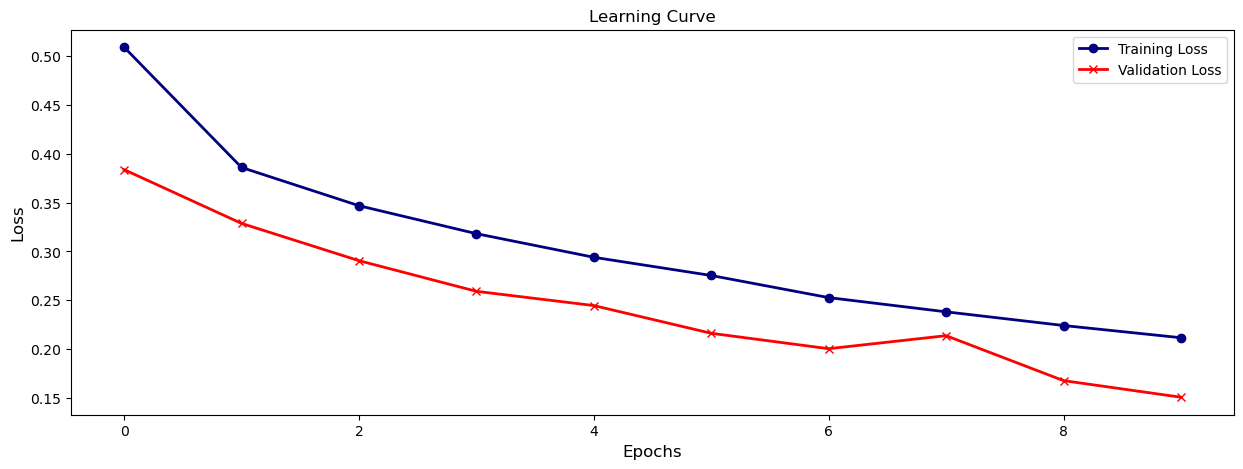

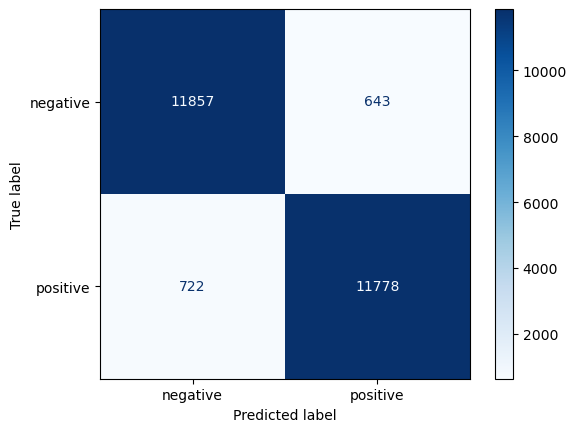


The training is completed!

Elapsed training time is: 1192.5688998699188 seconds (19.88 minutes)


In [23]:
# Call the training function
result = train(encoder, train_loader=train_dataloader, optimiser=optimiser, criterion=criterion, target_names=target_names, device=device, epochs=10)

The classification report is:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.85      0.87      0.86     12500
    positive       0.87      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


The confusion matrix is:
------------------------------------------------------------
[[10873  1627]
 [ 1882 10618]]


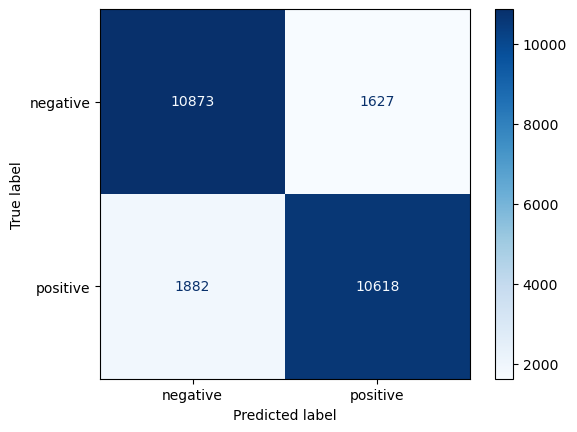


The testing is completed!


In [25]:
result = test(encoder, test_loader=test_dataloader, target_names=target_names, device=device, result_dict=result)

In [26]:
result['test']

{'negative': {'precision': 0.8524500196001568,
  'recall': 0.86984,
  'f1-score': 0.8610572163927935,
  'support': 12500.0},
 'positive': {'precision': 0.8671294405879951,
  'recall': 0.84944,
  'f1-score': 0.8581935744594867,
  'support': 12500.0},
 'accuracy': 0.85964,
 'macro avg': {'precision': 0.859789730094076,
  'recall': 0.85964,
  'f1-score': 0.8596253954261401,
  'support': 25000.0},
 'weighted avg': {'precision': 0.8597897300940761,
  'recall': 0.85964,
  'f1-score': 0.8596253954261401,
  'support': 25000.0}}